In [83]:
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

In [84]:
iris = load_iris()

In [85]:
X=pd.DataFrame(iris.data)
X.columns=iris.feature_names
y=iris.target


<Axes: xlabel='sepal length (cm)', ylabel='sepal width (cm)'>

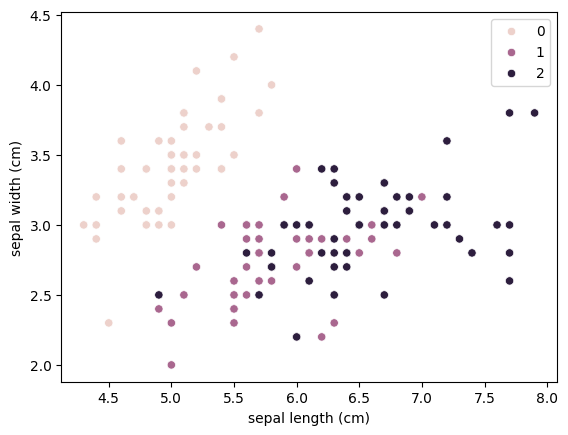

In [86]:
# visualization
sns.scatterplot(x=X['sepal length (cm)'],y=X['sepal width (cm)'],hue=y)

In [87]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)


<Axes: >

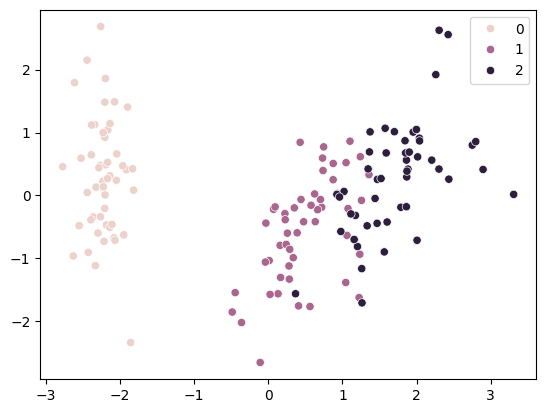

In [88]:
# optional - dimensionality reduction using PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=y)


In [89]:
#elbow method to find optimal number of clusters
wcss=[]
for i in range(1,11):
    kmeans=KMeans(n_clusters=i,random_state=42 , n_init=10)
    kmeans.fit(X_pca)
    wcss.append(kmeans.inertia_)

<Axes: >

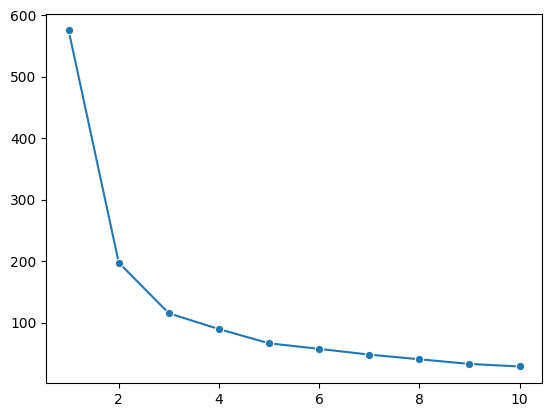

In [90]:
sns.lineplot(x=range(1,11),y=wcss,marker='o')

In [91]:
from kneed import KneeLocator

kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing')
print(kl.elbow)  # Will print 3 for Iris typically

3


In [92]:
kl = KneeLocator(range(1,11), wcss, curve='convex', direction='decreasing', S=0.5)
print(kl.elbow)  # Lower S = more sensitive = picks earlier elbow

3


<Axes: >

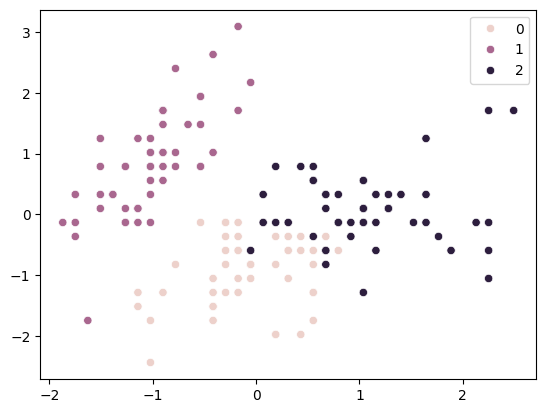

In [93]:
#kmeans
kmeans=KMeans(n_clusters=3, n_init=1)
labels=kmeans.fit_predict(X_scaled)
sns.scatterplot(x=X_scaled[:,0],y=X_scaled[:,1],hue=labels)

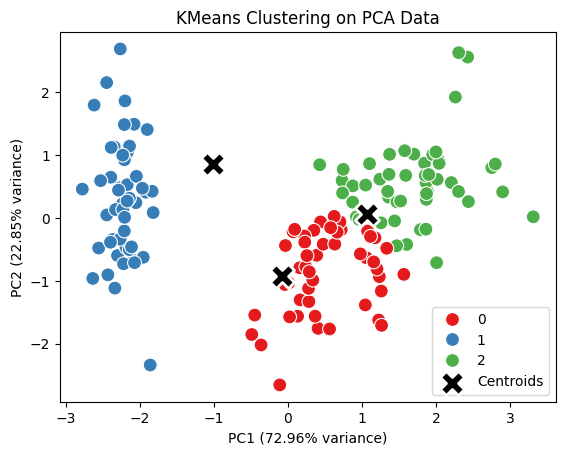

In [94]:
# Visualize PCA data with cluster labels
sns.scatterplot(x=X_pca[:,0],y=X_pca[:,1],hue=labels,palette='Set1',s=100)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='black', marker='X', s=300, edgecolors='white', linewidth=2, label='Centroids')
plt.title('KMeans Clustering on PCA Data')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.legend()
plt.show()